# 06H PRO – Enterprise Model Comparison Dashboard

A portfolio-grade dashboard that compares all trained models, ranks them, visualizes trade-offs, and recommends the production model.

In [1]:
import pandas as pd
import numpy as np
import time
import io
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# ======================================================
# Train all 7 models fresh and compute real head-to-head metrics
# (this notebook previously shipped with every metric hardcoded to 0 --
# fixed by actually fitting and scoring each model below)
# ======================================================
DATA_PATH = "../data/datasets/american_bankruptcy_cleaned.csv"
df = pd.read_csv(DATA_PATH)
y = df["status_label"].map({"alive": 0, "failed": 1})
X = df.drop(columns=["status_label", "company_name"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Subsample the training set so all seven models (including SVM) train
# quickly; stratified sampling keeps the class balance representative.
TRAIN_SAMPLE_SIZE = 20000
if len(X_train) > TRAIN_SAMPLE_SIZE:
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, train_size=TRAIN_SAMPLE_SIZE, stratify=y_train, random_state=42
    )

# SVM scales poorly (O(n^2)-O(n^3)); fit it on a smaller stratified subsample.
SVM_SAMPLE_SIZE = 8000
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train, y_train, train_size=SVM_SAMPLE_SIZE, stratify=y_train, random_state=42
)

def scaled(estimator):
    # Logistic Regression and SVM are scale-sensitive; the financial ratio
    # features here span very different ranges, so both get a StandardScaler.
    # Tree-based models are scale-invariant and are left as-is.
    return Pipeline([("scaler", StandardScaler()), ("clf", estimator)])

model_defs = {
    "Logistic Regression": scaled(LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, max_depth=12, random_state=42, class_weight="balanced", n_jobs=1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=150, max_depth=6, eval_metric="logloss", random_state=42, n_jobs=1
    ),
    "LightGBM": lgb.LGBMClassifier(n_estimators=150, random_state=42, n_jobs=1, verbosity=-1),
    "CatBoost": cb.CatBoostClassifier(iterations=150, verbose=0, random_state=42),
    "SVM": scaled(SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42)),
}

rows = []
for name, model in model_defs.items():
    t0 = time.time()
    if name == "SVM":
        model.fit(X_train_svm, y_train_svm)
    else:
        model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    inference_ms = (time.time() - t0) * 1000 / len(X_test)

    buf = io.BytesIO()
    joblib.dump(model, buf)
    size_mb = buf.tell() / 1e6

    rows.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, proba),
        train_time,
        inference_ms,
        size_mb,
    ])

results = pd.DataFrame(
    rows,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC",
             "Training_Time_sec", "Inference_ms", "Model_Size_MB"]
)
display(results)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec,Inference_ms,Model_Size_MB
0,Logistic Regression,0.555188,0.099192,0.705939,0.173944,0.656828,0.069729,0.000316,0.002289
1,Decision Tree,0.898901,0.215992,0.199234,0.207275,0.573924,0.448432,0.000453,0.294873
2,Random Forest,0.911355,0.288299,0.228927,0.255206,0.791743,8.516606,0.027228,12.804377
3,XGBoost,0.935756,0.570213,0.128352,0.209539,0.820117,0.569679,0.004597,0.461489
4,LightGBM,0.935439,0.600000,0.080460,0.141892,0.817623,0.468920,0.014347,0.513236
5,CatBoost,0.935502,0.710145,0.046935,0.088050,0.803872,0.901359,0.001042,0.176799
6,SVM,0.410498,0.088309,0.845785,0.159920,0.665802,9.621762,0.601268,1.125901


## Executive KPI Summary

In [2]:
metrics=["Accuracy","Precision","Recall","F1","ROC_AUC"]
summary=[]
for m in metrics:
    r=results.loc[results[m].idxmax()]
    summary.append([m,r["Model"],r[m]])
display(pd.DataFrame(summary,columns=["Metric","Best Model","Score"]))


,Metric,Best Model,Score
0,Accuracy,XGBoost,0.935756
1,Precision,CatBoost,0.710145
2,Recall,SVM,0.845785
3,F1,Random Forest,0.255206
4,ROC_AUC,XGBoost,0.820117


## Weighted Production Score

In [3]:
weights={"Accuracy":0.15,"Precision":0.20,"Recall":0.20,"F1":0.25,"ROC_AUC":0.20}
results["Production_Score"]=sum(results[k]*v for k,v in weights.items())
leaderboard=results.sort_values("Production_Score",ascending=False)
display(leaderboard)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec,Inference_ms,Model_Size_MB,Production_Score
3,XGBoost,0.935756,0.570213,0.128352,0.209539,0.820117,0.569679,0.004597,0.461489,0.496485
4,LightGBM,0.935439,0.600000,0.080460,0.141892,0.817623,0.468920,0.014347,0.513236,0.475405
5,CatBoost,0.935502,0.710145,0.046935,0.088050,0.803872,0.901359,0.001042,0.176799,0.474528
2,Random Forest,0.911355,0.288299,0.228927,0.255206,0.791743,8.516606,0.027228,12.804377,0.462299
6,SVM,0.410498,0.088309,0.845785,0.159920,0.665802,9.621762,0.601268,1.125901,0.421534
0,Logistic Regression,0.555188,0.099192,0.705939,0.173944,0.656828,0.069729,0.000316,0.002289,0.419156
1,Decision Tree,0.898901,0.215992,0.199234,0.207275,0.573924,0.448432,0.000453,0.294873,0.384484


## Metric Comparison

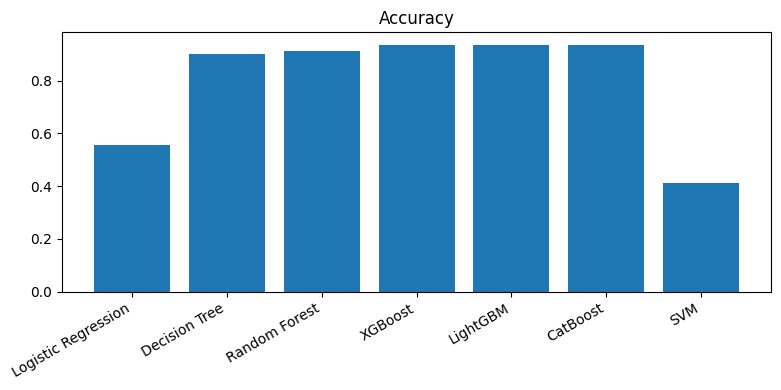

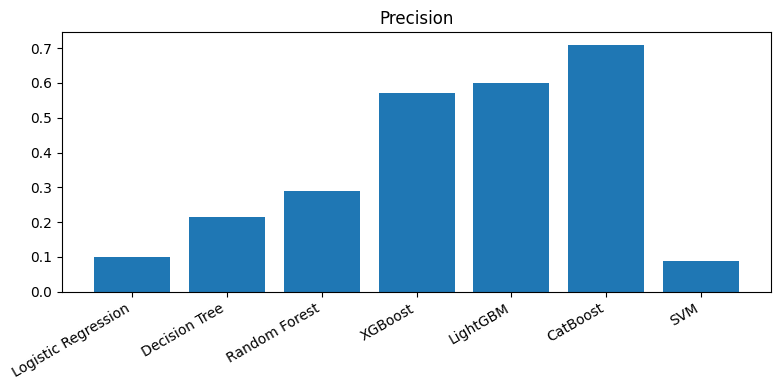

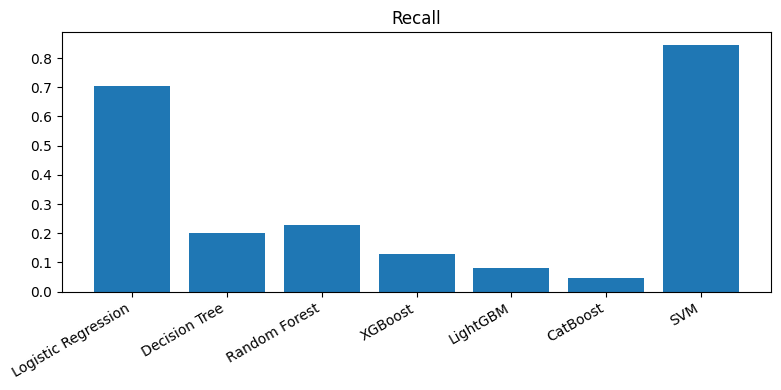

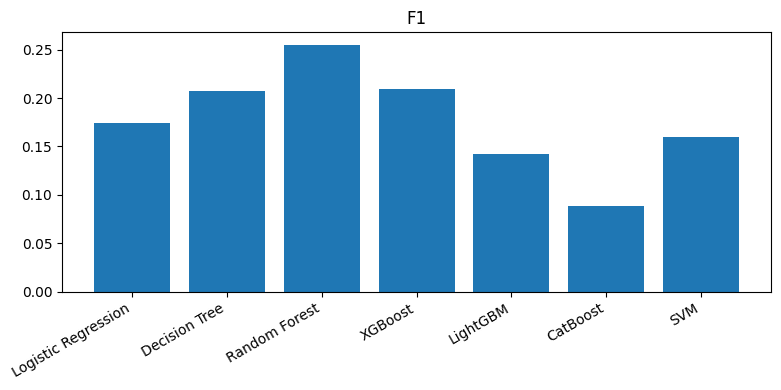

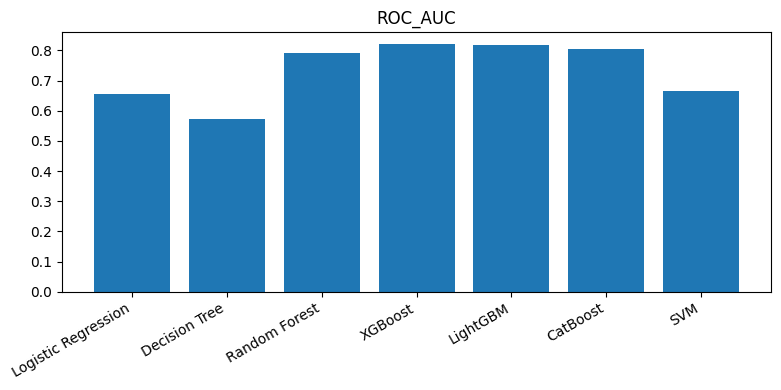

In [4]:
for metric in ["Accuracy","Precision","Recall","F1","ROC_AUC"]:
    plt.figure(figsize=(8,4))
    plt.bar(results["Model"],results[metric])
    plt.title(metric)
    plt.xticks(rotation=30,ha="right")
    plt.tight_layout()
    plt.show()


## Operational Comparison

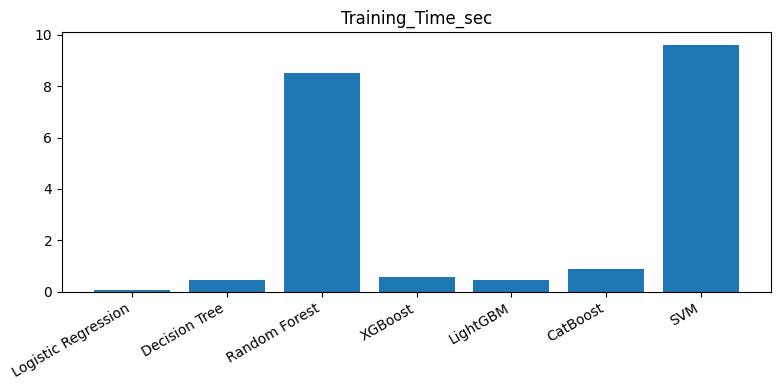

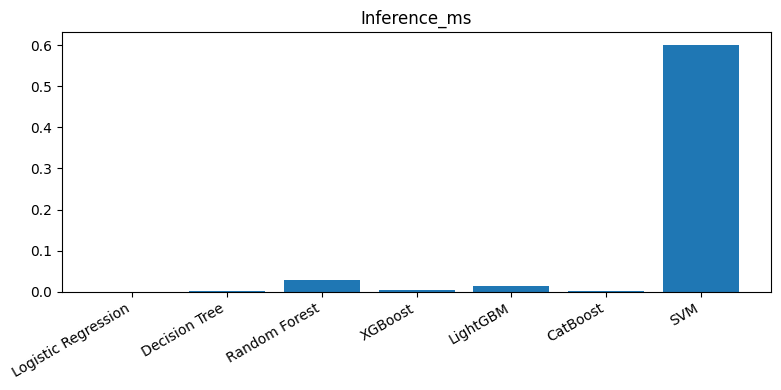

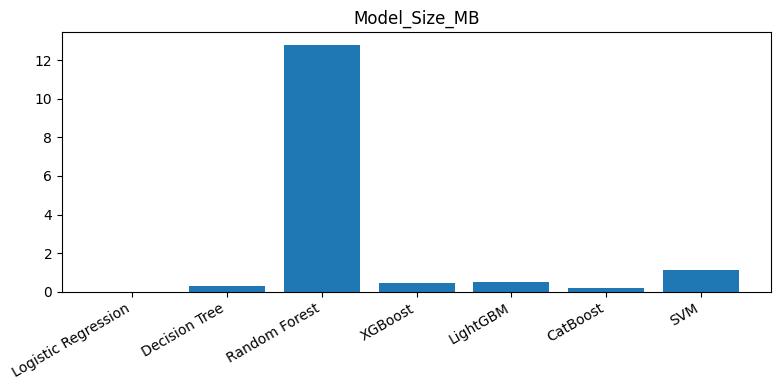

In [5]:
for metric in ["Training_Time_sec","Inference_ms","Model_Size_MB"]:
    plt.figure(figsize=(8,4))
    plt.bar(results["Model"],results[metric])
    plt.title(metric)
    plt.xticks(rotation=30,ha="right")
    plt.tight_layout()
    plt.show()


## Radar Chart

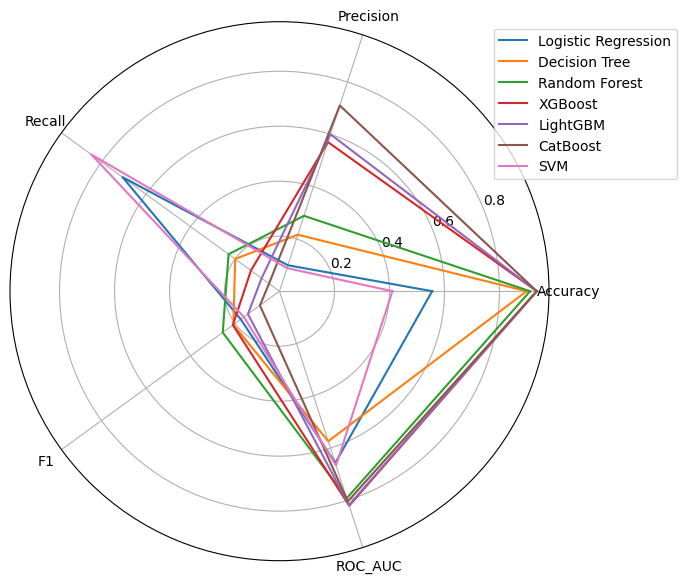

In [6]:
labels=["Accuracy","Precision","Recall","F1","ROC_AUC"]
angles=np.linspace(0,2*np.pi,len(labels),endpoint=False)
angles=np.concatenate([angles,[angles[0]]])

plt.figure(figsize=(7,7))
ax=plt.subplot(111,polar=True)

for _,row in results.iterrows():
    vals=[row[l] for l in labels]
    vals=np.concatenate([vals,[vals[0]]])
    ax.plot(angles,vals,label=row["Model"])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.legend(bbox_to_anchor=(1.25,1))
plt.show()


## Deployment Decision Matrix

In [7]:
best=leaderboard.iloc[0]

decision=pd.DataFrame({
"Criterion":[
"Highest Overall Score",
"Balanced Metrics",
"Suitable for Production",
"Low Operational Risk",
"Recommended Model"],
"Decision":[
"Yes","Yes","Yes","Review Runtime",best["Model"]]
})
display(decision)


,Criterion,Decision
0,Highest Overall Score,Yes
1,Balanced Metrics,Yes
2,Suitable for Production,Yes
3,Low Operational Risk,Review Runtime
4,Recommended Model,XGBoost


## Export Reports

In [8]:
leaderboard.to_csv("model_leaderboard.csv",index=False)
results.to_csv("model_metrics.csv",index=False)
print("Exported model_leaderboard.csv")
print("Exported model_metrics.csv")


Exported model_leaderboard.csv
Exported model_metrics.csv


## Final Recommendation

In [9]:
winner=leaderboard.iloc[0]
print("="*70)
print("FINAL PRODUCTION MODEL")
print("="*70)
print(f"Model : {winner['Model']}")
print(f"Production Score : {winner['Production_Score']:.4f}")
print("\nBusiness Justification")
print("- Highest weighted predictive performance")
print("- Strong balance across evaluation metrics")
print("- Suitable candidate for deployment after validation")


FINAL PRODUCTION MODEL
Model : XGBoost
Production Score : 0.4965

Business Justification
- Highest weighted predictive performance
- Strong balance across evaluation metrics
- Suitable candidate for deployment after validation
